In [1]:
import numpy as np

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)


c:\Users\revaa\anaconda3\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch: 2.5.1
device: cpu


Total images found: 1079


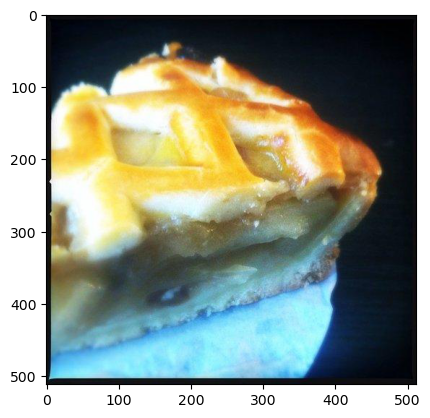

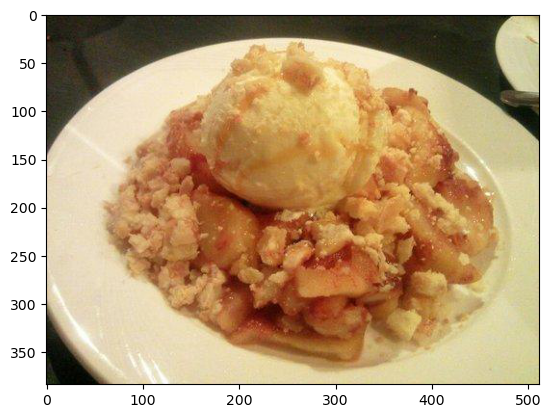

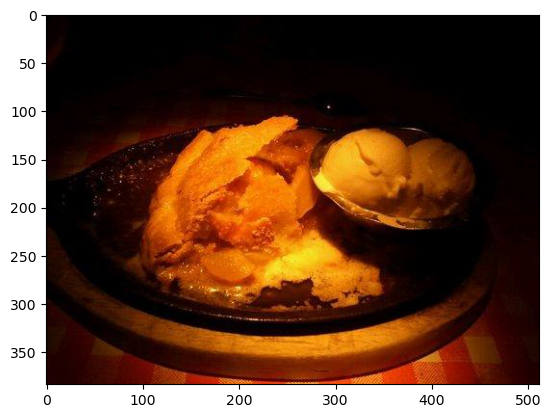

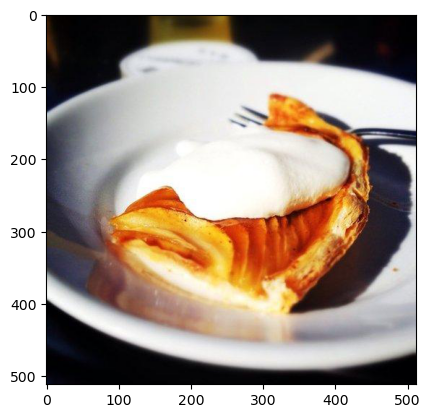

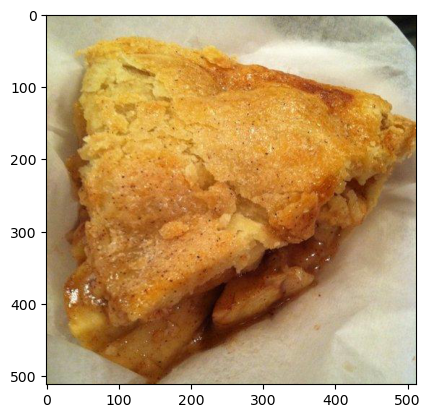

In [18]:
from pathlib import Path

train_dir = Path("ucsc-cse-144-spring-2026-final-project/train")

# This looks specifically for: train_dir / any_folder / any_image.jpg
image_paths = sorted(list(train_dir.glob("*/*.jpg")))

print(f"Total images found: {len(image_paths)}")

from PIL import Image
def open(image_path):
    return Image.open(image_path).convert("RGB")

for image_path in image_paths[:5]:
    image = open(image_path)
    plt.imshow(image)
    plt.show()


Data Augmentation & Data prep

In [17]:
import torch
from torchvision import transforms
from PIL import Image

train_transforms = transforms.Compose([
    transforms.Resize((214,214)),
    transforms.ToTensor(),
])

Model